In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style("darkgrid")
sns.set_palette("husl")

# Load data
matches = pd.read_csv('../data/matches.csv')
deliveries = pd.read_csv('../data/deliveries.csv')

print("✅ Matches:", matches.shape)
print("✅ Deliveries:", deliveries.shape)
matches.head()


✅ Matches: (1095, 20)
✅ Deliveries: (260920, 17)


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [2]:
# ── Data Overview ──────────────────────────────────────────
print("=" * 50)
print("MATCHES - Missing Values:")
print(matches.isnull().sum()[matches.isnull().sum() > 0])

print("\nSEASONS COVERED:", sorted(matches['season'].unique()))
print("TOTAL TEAMS:", matches['team1'].nunique())
print("TOTAL VENUES:", matches['venue'].nunique())
print("TOTAL CITIES:", matches['city'].nunique())

# Fix: Drop rows where winner is null (abandoned matches)
matches = matches.dropna(subset=['winner'])
print(f"\n✅ After removing abandoned matches: {len(matches)} matches")

MATCHES - Missing Values:
city                 51
player_of_match       5
winner                5
result_margin        19
target_runs           3
target_overs          3
method             1074
dtype: int64

SEASONS COVERED: ['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024']
TOTAL TEAMS: 19
TOTAL VENUES: 58
TOTAL CITIES: 36

✅ After removing abandoned matches: 1090 matches


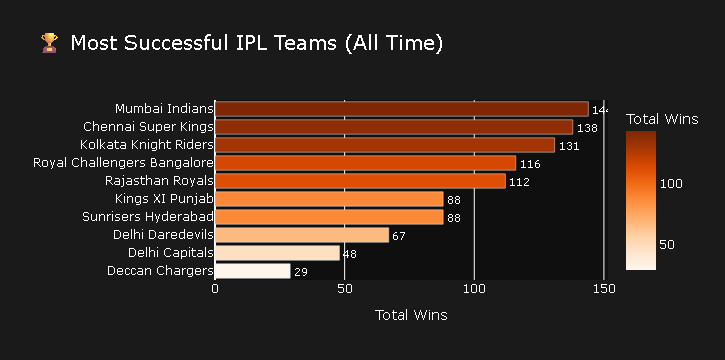

In [3]:
# ── ANALYSIS 1: Most Successful Teams ─────────────────────
win_counts = matches['winner'].value_counts().reset_index()
win_counts.columns = ['team', 'wins']

fig = px.bar(
    win_counts.head(10),
    x='wins', y='team',
    orientation='h',
    color='wins',
    color_continuous_scale='Oranges',
    title='🏆 Most Successful IPL Teams (All Time)',
    labels={'wins': 'Total Wins', 'team': ''},
    text='wins'
)
fig.update_layout(
    plot_bgcolor='#0f0f0f',
    paper_bgcolor='#1a1a1a',
    font_color='white',
    title_font_size=20,
    showlegend=False,
    yaxis={'categoryorder': 'total ascending'}
)
fig.update_traces(textposition='outside', textfont_color='white')
fig.show()

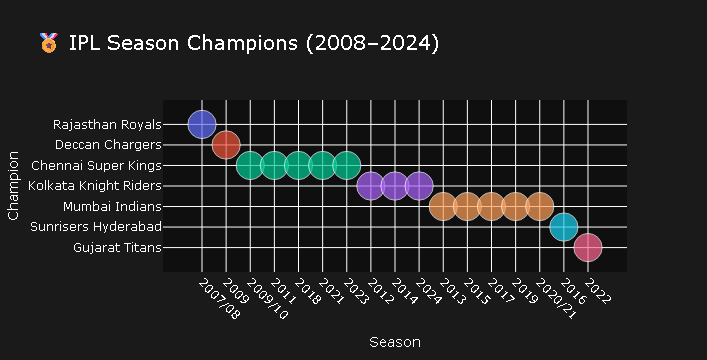

In [4]:
# ── ANALYSIS 2: IPL Season Champions ──────────────────────
# Get winner of each season (final match)
finals = matches[matches['match_type'] == 'Final'][['season', 'winner']]

fig = px.scatter(
    finals,
    x='season', y='winner',
    color='winner',
    size=[30]*len(finals),
    title='🏅 IPL Season Champions (2008–2024)',
    labels={'season': 'Season', 'winner': 'Champion'},
)
fig.update_layout(
    plot_bgcolor='#0f0f0f',
    paper_bgcolor='#1a1a1a',
    font_color='white',
    title_font_size=20,
    showlegend=False,
    xaxis_tickangle=45
)
fig.show()

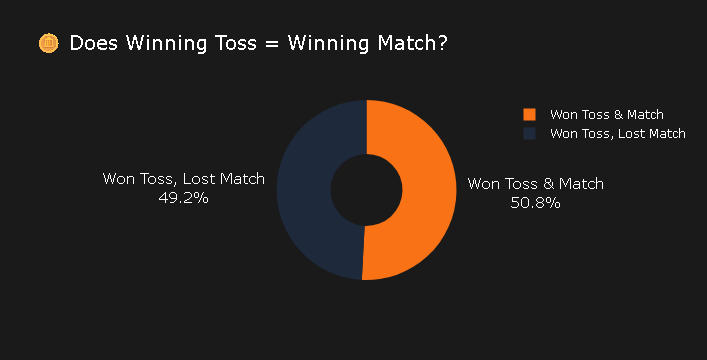

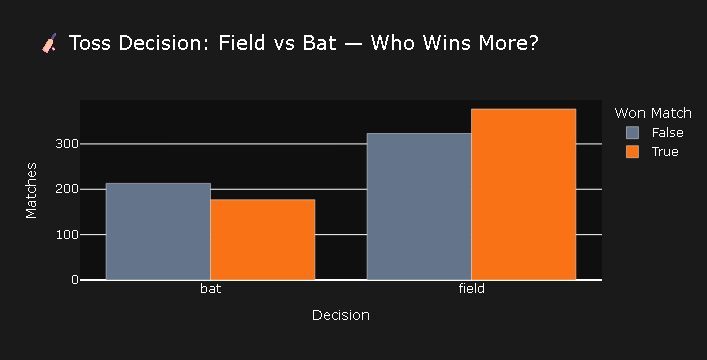

In [5]:
# ── ANALYSIS 3: Toss Impact on Match Result ───────────────
matches['toss_match_winner'] = matches['toss_winner'] == matches['winner']

toss_impact = matches['toss_match_winner'].value_counts().reset_index()
toss_impact.columns = ['toss_won_match', 'count']
toss_impact['label'] = toss_impact['toss_won_match'].map({True: 'Won Toss & Match', False: 'Won Toss, Lost Match'})

fig = px.pie(
    toss_impact,
    values='count',
    names='label',
    title='🪙 Does Winning Toss = Winning Match?',
    color_discrete_sequence=['#f97316', '#1e293b'],
    hole=0.4
)
fig.update_layout(
    plot_bgcolor='#0f0f0f',
    paper_bgcolor='#1a1a1a',
    font_color='white',
    title_font_size=20,
)
fig.update_traces(textfont_size=15, textinfo='percent+label')
fig.show()

# Toss decision breakdown
decision = matches.groupby(['toss_decision', 'toss_match_winner']).size().reset_index(name='count')
fig2 = px.bar(
    decision,
    x='toss_decision', y='count',
    color='toss_match_winner',
    barmode='group',
    title='🏏 Toss Decision: Field vs Bat — Who Wins More?',
    color_discrete_map={True: '#f97316', False: '#64748b'},
    labels={'toss_decision': 'Decision', 'count': 'Matches', 'toss_match_winner': 'Won Match'}
)
fig2.update_layout(
    plot_bgcolor='#0f0f0f',
    paper_bgcolor='#1a1a1a',
    font_color='white',
    title_font_size=20,
)
fig2.show()

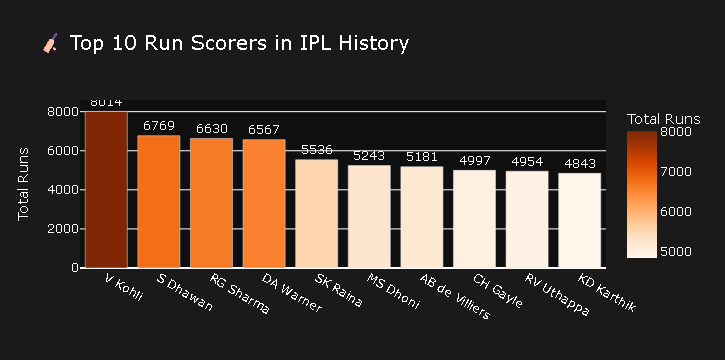

In [6]:
# ── ANALYSIS 4: Top Run Scorers ───────────────────────────
top_batsmen = deliveries.groupby('batter')['batsman_runs'].sum().reset_index()
top_batsmen.columns = ['batter', 'total_runs']
top_batsmen = top_batsmen.sort_values('total_runs', ascending=False).head(10)

fig = px.bar(
    top_batsmen,
    x='batter', y='total_runs',
    color='total_runs',
    color_continuous_scale='Oranges',
    title='🏏 Top 10 Run Scorers in IPL History',
    labels={'batter': '', 'total_runs': 'Total Runs'},
    text='total_runs'
)
fig.update_layout(
    plot_bgcolor='#0f0f0f',
    paper_bgcolor='#1a1a1a',
    font_color='white',
    title_font_size=20,
    showlegend=False,
    xaxis_tickangle=30
)
fig.update_traces(textposition='outside', textfont_color='white')
fig.show()

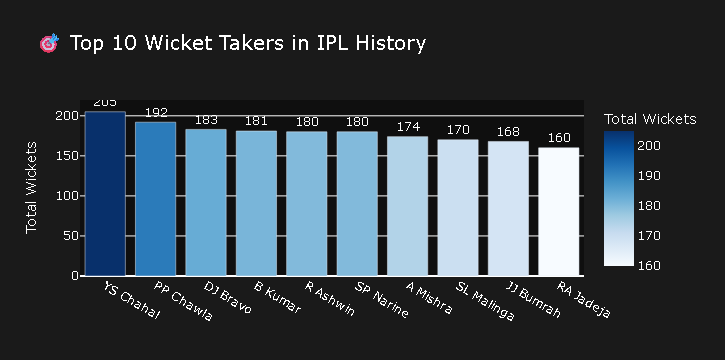

In [7]:
# ── ANALYSIS 5: Top Wicket Takers ─────────────────────────
wickets = deliveries[deliveries['is_wicket'] == 1]
wickets = wickets[~wickets['dismissal_kind'].isin(['run out', 'retired hurt', 'obstructing the field'])]

top_bowlers = wickets.groupby('bowler')['is_wicket'].count().reset_index()
top_bowlers.columns = ['bowler', 'wickets']
top_bowlers = top_bowlers.sort_values('wickets', ascending=False).head(10)

fig = px.bar(
    top_bowlers,
    x='bowler', y='wickets',
    color='wickets',
    color_continuous_scale='Blues',
    title='🎯 Top 10 Wicket Takers in IPL History',
    labels={'bowler': '', 'wickets': 'Total Wickets'},
    text='wickets'
)
fig.update_layout(
    plot_bgcolor='#0f0f0f',
    paper_bgcolor='#1a1a1a',
    font_color='white',
    title_font_size=20,
    showlegend=False,
    xaxis_tickangle=30
)
fig.update_traces(textposition='outside', textfont_color='white')
fig.show()

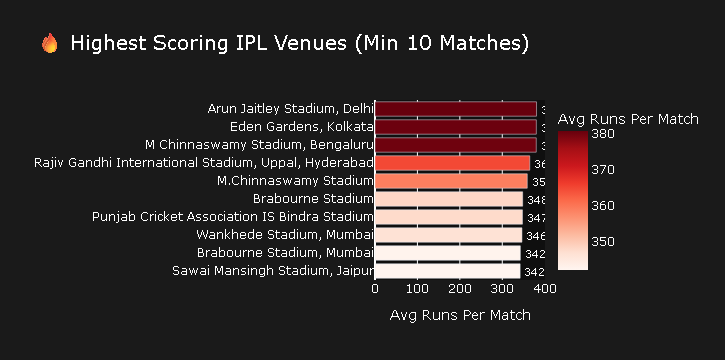

In [8]:
# ── ANALYSIS 6: Highest Scoring Venues ────────────────────
venue_scores = deliveries.merge(matches[['id','venue']], left_on='match_id', right_on='id')
venue_avg = venue_scores.groupby('venue')['total_runs'].sum().reset_index()
venue_avg.columns = ['venue', 'total_runs']

# Matches per venue
matches_per_venue = matches['venue'].value_counts().reset_index()
matches_per_venue.columns = ['venue', 'matches']

venue_avg = venue_avg.merge(matches_per_venue, on='venue')
venue_avg['avg_runs_per_match'] = (venue_avg['total_runs'] / venue_avg['matches']).round(1)
venue_avg = venue_avg[venue_avg['matches'] >= 10].sort_values('avg_runs_per_match', ascending=False).head(10)

fig = px.bar(
    venue_avg,
    x='avg_runs_per_match', y='venue',
    orientation='h',
    color='avg_runs_per_match',
    color_continuous_scale='Reds',
    title='🔥 Highest Scoring IPL Venues (Min 10 Matches)',
    labels={'avg_runs_per_match': 'Avg Runs Per Match', 'venue': ''},
    text='avg_runs_per_match'
)
fig.update_layout(
    plot_bgcolor='#0f0f0f',
    paper_bgcolor='#1a1a1a',
    font_color='white',
    title_font_size=20,
    showlegend=False,
    yaxis={'categoryorder': 'total ascending'}
)
fig.update_traces(textposition='outside', textfont_color='white')
fig.show()

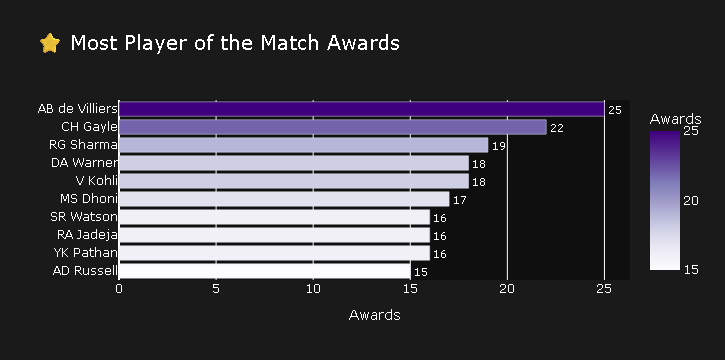

In [9]:
# ── ANALYSIS 7: Player of the Match Kings ─────────────────
potm = matches['player_of_match'].value_counts().reset_index().head(10)
potm.columns = ['player', 'awards']

fig = px.bar(
    potm,
    x='awards', y='player',
    orientation='h',
    color='awards',
    color_continuous_scale='Purples',
    title='⭐ Most Player of the Match Awards',
    labels={'awards': 'Awards', 'player': ''},
    text='awards'
)
fig.update_layout(
    plot_bgcolor='#0f0f0f',
    paper_bgcolor='#1a1a1a',
    font_color='white',
    title_font_size=20,
    showlegend=False,
    yaxis={'categoryorder': 'total ascending'}
)
fig.update_traces(textposition='outside', textfont_color='white')
fig.show()

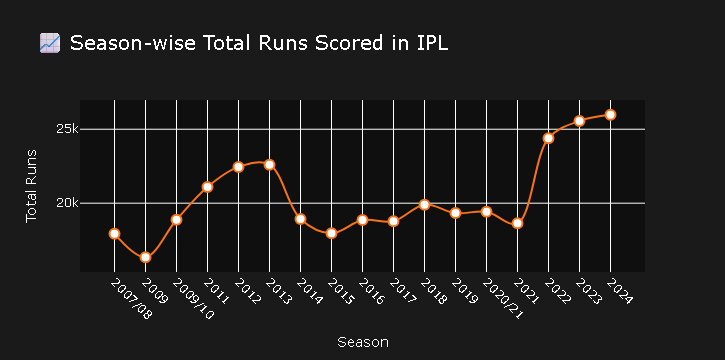

In [10]:
# ── ANALYSIS 8: Season-wise Total Runs Trend ──────────────
season_runs = deliveries.merge(matches[['id','season']], left_on='match_id', right_on='id')
season_total = season_runs.groupby('season')['total_runs'].sum().reset_index()
season_total.columns = ['season', 'total_runs']

fig = px.line(
    season_total,
    x='season', y='total_runs',
    title='📈 Season-wise Total Runs Scored in IPL',
    labels={'season': 'Season', 'total_runs': 'Total Runs'},
    markers=True,
    line_shape='spline'
)
fig.update_traces(
    line_color='#f97316',
    marker=dict(size=10, color='white', line=dict(width=2, color='#f97316'))
)
fig.update_layout(
    plot_bgcolor='#0f0f0f',
    paper_bgcolor='#1a1a1a',
    font_color='white',
    title_font_size=20,
    xaxis_tickangle=45
)
fig.show()